# Seeing accuray FAIL for a different problem

**Our Mission**: Apply our evaluation toolkit to a dataset where accuracy is a dangerous lie and witness why our new metrics are essential for survival. We'll also introduce the right tool for this specific pathology: the **AUC-ROC curve**.

**Our Crucible**: The Credit Card Fraud Detection dataset from Kaggle. It is a classic, heavily imbalanced dataset. It contains transactions made by credit cards in September 2013 by European cardholders. The dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The positive class (frauds) account for only 0.172% of all transactions.

1. Dataset : Credit Card Fraud EDA
First, you'll need to download the dataset from [here](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud.)
and place `creditcard.csv` in your working directory.

In [1]:
# Load the dataset
import pandas as pd
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('creditcard.csv')
    df = pd.DataFrame(df)
except FileNotFoundError:
    print("Please download 'creditcard.csv' from Kaggle and place it in this directory.")

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:

print("\nDataset INFO")
print(df.info())
print(f"Missing values in the dataset : {df.isnull().sum()}")



Dataset INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

Class
0    284315
1       492
Name: count, dtype: int64


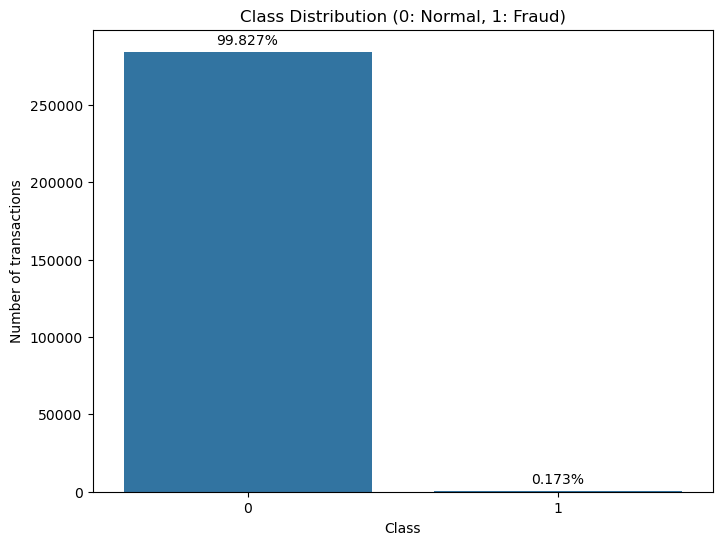

In [4]:
import seaborn as sns
# Class IMbalance analysis
class_counts = df['Class'].value_counts()
print(class_counts)


plt.figure(figsize=(8,6))
sns.countplot(x = 'Class', data = df)
plt.title('Class Distribution (0: Normal, 1: Fraud)')
plt.ylabel('Number of transactions')
plt.xlabel("Class")

# Annotate with percentages
total = len(df)
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2.,
            height + 5000,
            f'{height/total:.3%}',
            ha="center")
plt.show()




We will build a simple Multi-Layer Perceptron (MLP) for this tabular data and use our existing evaluation logic. We'll see first-hand how accuracy can create a devastating illusion of success.

In [5]:
import torch
from torch import nn
import torch.optim as optim
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# IF GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
BS = 256
EPOCH = 10
seed = 42
LR = 0.001
# For reproducibility

np.random.seed(42)
torch.manual_seed((42))

# Seperate features and labels
X = df.drop('Class', axis=1).values
y = df['Class'].values

# Scale the data ( Important for ANNs )
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,random_state=seed, stratify=y)

# Convert to pt tensors

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

# Create Tensor Datasets and DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)


train_loader_fraud = DataLoader(train_dataset, batch_size=BS, shuffle=True)
test_loader_fraud = DataLoader(test_dataset, batch_size=BS, shuffle=False)

class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2) # coz we have 2 classes
        )
    def forward(self, x):
        return (self.layers(x))
    
fraud_model = FraudMLP(X_train.shape[1]).to(device)

criterion_fraud = nn.CrossEntropyLoss()
optimizer = optim.Adam(fraud_model.parameters(), lr = LR)

# Training loop
for epoch in range(EPOCH):
    for inputs, labels in tqdm(train_loader_fraud, desc=f"Epoch {epoch+1}/{EPOCH}"):
        inputs, labels = inputs.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs = fraud_model(inputs)
        loss = criterion_fraud(outputs, labels)
        loss.backward()
        optimizer.step()

print("Finished Fraud model training ")

c:\Users\hp\anaconda3\envs\basic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epoch 10/10: 100%|██████████| 891/891 [00:11<00:00, 78.06it/s] 

Finished Fraud model training 


In [6]:
# Evaluation
import torchmetrics
from torchmetrics import (
    Accuracy,
    Precision,
    Recall,
    F1Score
)

fraud_model.eval()
acc_metric_b = Accuracy(task="binary").to(device)
precision_b  = Precision(task='binary').to(device)
recall       = Recall(task='binary').to(device)
f1_metric_b  = F1Score(task='binary').to(device)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader_fraud, desc="Evaluating fraud model"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = fraud_model(inputs)
        preds = torch.argmax(outputs, dim=1)

        acc_metric_b.update(preds, labels)
        precision_b.update(preds, labels)  
        recall.update(preds, labels)       
        f1_metric_b.update(preds, labels)  

# Compute and print the results
accuracy_b = acc_metric_b.compute()
precision_b = precision_b.compute()
recall_b = recall.compute()
f1_b = f1_metric_b.compute()

print("\nSee how the accuracy is 99.93")
print(f"Overall Accuracy: {accuracy_b*100:.4f}")
print("--- Reality Check ---")
print(f"Precision for Fraud Class: {precision_b*100:.4f}")
print(f"Recall for Fraud Class: {recall_b*100:.4f}")
print(f"F1-Score for Fraud Class: {f1_b*100:.4f}")

c:\Users\hp\anaconda3\envs\basic\lib\site-packages\torchmetrics\utilities\imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Evaluating fraud model: 100%|██████████| 223/223 [00:03<00:00, 60.58it/s]



See how the accuracy is 99.93
Overall Accuracy: 99.9368
--- Reality Check ---
Precision for Fraud Class: 81.0000
Recall for Fraud Class: 82.6531
F1-Score for Fraud Class: 81.8182


### This is why other metrics exist. 
> Look at those results! An accuracy of ~99.9% feels like a massive success. But then you look at the recall. It is 82%. This means we are failing to catch a significant portion of the actual fraud cases. Our "highly accurate" model is terrible at its one real job.

## The right metric for this kind of job is AUC-ROC:
*For imbalanced binary classification, a much better metric is the Area Under the Receiver Operating Characteristic Curve (AUC-ROC)*

### Definition : 

The ROC curve plots Recall (True Positive Rate) vs. the False Positive Rate (FP / (FP + TN)) at every possible classification threshold. A random model has an AUC of 0.5. A perfect model has an AUC of 1.0. It measures the model's ability to discriminate between the positive and negative classes, regardless of the final threshold you choose.

Calculating AUROC: 100%|██████████| 223/223 [00:01<00:00, 154.70it/s]


Model AUROC Score 97.92


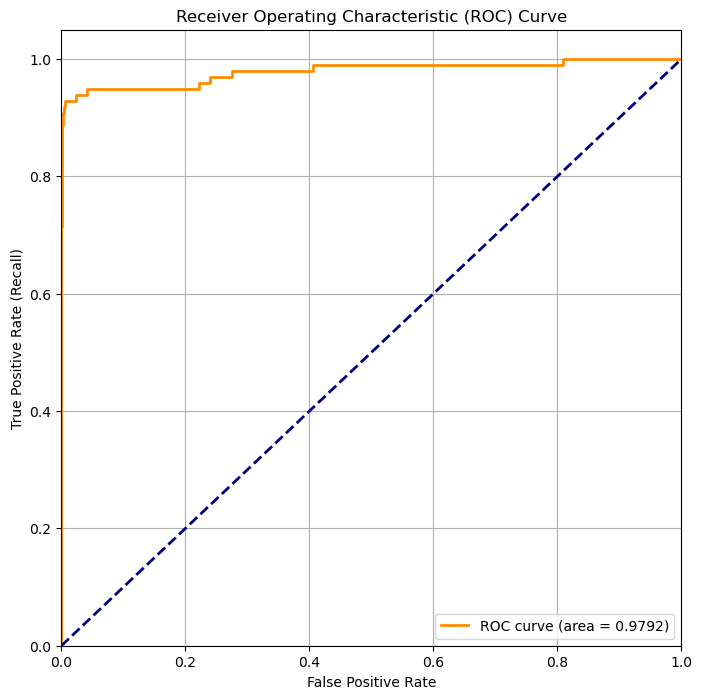

In [7]:
# Implementing and visualizing AUC-ROC
from torchmetrics import AUROC
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
fraud_model.eval()

# Initialize the AUROC class
auroc_metric = AUROC(task='binary').to(device)

all_labels = []
all_probs  = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader_fraud, desc=f"Calculating AUROC"):
        outputs = fraud_model(inputs)
        # For AUROC, we need the probability of the POSITIVE class (class 1)
        probs = F.softmax(outputs, dim=1)[:,1]

        auroc_metric.update(probs, labels)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Compute the final metric
auroc_score = auroc_metric.compute()
print(f"Model AUROC Score {auroc_score*100:.2f}")


# Visualize the ROC Curve using scikit-learn
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



## Explorations

* **Beginner**: 

Manually calculate the confusion matrix for the fraud model using `torchmetrics.ConfusionMatrix`. How many true frauds (True Positives) did we catch, and how many did we miss (False Negatives)? How does this visually explain the poor recall score?

* **Intermediate**: 

The `CrossEntropyLoss` treats both classes equally. This is a problem when one class is 1000x more important. Research and implement a `weighted loss function.` Create a `weights` tensor based on the class imbalance `(weights = torch.tensor([0.1, 0.9], device=device))` and pass it to `nn.CrossEntropyLoss(weight=weights)`. Retrain the model. How do precision, recall, and AUROC change?

* **Advanced**: 

Research the Precision-Recall Curve (PRC) and the AUPRC metric. For severely imbalanced datasets, AUPRC is often considered more informative than AUROC. Implement the AUPRC calculation using torchmetrics.AveragePrecision and plot the curve. Why might focusing on precision and recall be more useful than True/False Positive Rates when the number of true negatives is overwhelmingly large?

### Easy

________

__________________

______________

In [12]:
## Beginner
from torchmetrics import ConfusionMatrix

cmo  = ConfusionMatrix(task='binary').to(device)
fraud_model.eval()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader_fraud, desc="Evaluating"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = fraud_model(inputs).to(device)

        cmo.update(outputs[:,0], labels)

cmo_final = cmo.compute()

print(cmo_final)

Evaluating: 100%|██████████| 223/223 [00:03<00:00, 60.50it/s] 

tensor([[   21, 56843],
        [   83,    15]], device='cuda:0')


### Intermediate

________________________________________________

__________________________________________

____________________________________

In [ ]:

weights = torch.tensor([0.1, 0.9], device=device)
criterion_fraud = nn.CrossEntropyLoss(weight=weights)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
precision = torchmetrics.Precision(task="binary").to(device)
recall = torchmetrics.Recall(task="binary").to(device)
f1 = torchmetrics.F1Score(task="binary").to(device)
auroc = torchmetrics.AUROC(task="binary").to(device)
for epoch in range(EPOCH):
    fraud_model.train()
    running_loss = 0.0
    # Reset metrics each epoch
    accuracy.reset()
    precision.reset()
    recall.reset()
    f1.reset()
    auroc.reset()
    for inputs, labels in tqdm(train_loader_fraud, desc=f"Epoch {epoch+1}/{EPOCH}"):
        inputs, labels = inputs.to(device), labels.to(device)
        # Forward + backward
        optimizer.zero_grad()
        outputs = fraud_model(inputs)
        loss = criterion_fraud(outputs, labels)
        loss.backward()
        optimizer.step()
        # Accumulate loss
        running_loss += loss.item() * inputs.size(0)
        # Update metrics
        preds = torch.argmax(outputs, dim=1)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        accuracy.update(preds, labels)
        precision.update(preds, labels)
        recall.update(preds, labels)
        f1.update(preds, labels)
        auroc.update(probs, labels)
    # Compute average stats
    epoch_loss = running_loss / len(train_loader_fraud.dataset)
    acc = accuracy.compute().item()
    prec = precision.compute().item()
    rec = recall.compute().item()
    f1_score = f1.compute().item()
    auc = auroc.compute().item()
    print(
        f"Epoch [{epoch+1}/{EPOCH}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Acc: {acc:.4f} | "
        f"Prec: {prec:.4f} | "
        f"Rec: {rec:.4f} | "
        f"F1: {f1_score:.4f} | "
        f"AUROC: {auc:.4f}"
    )


Epoch 1/10: 100%|██████████| 891/891 [00:33<00:00, 26.57it/s]


Epoch [1/10] | Loss: 0.0085 | Acc: 0.9993 | Prec: 0.7793 | Rec: 0.8604 | F1: 0.8179 | AUROC: 0.9967


Epoch 2/10: 100%|██████████| 891/891 [00:33<00:00, 26.70it/s]


Epoch [2/10] | Loss: 0.0068 | Acc: 0.9995 | Prec: 0.8294 | Rec: 0.9010 | F1: 0.8637 | AUROC: 0.9980


Epoch 3/10: 100%|██████████| 891/891 [00:31<00:00, 28.12it/s]


...

Epoch [8/10] | Loss: 0.0055 | Acc: 0.9995 | Prec: 0.8167 | Rec: 0.9162 | F1: 0.8636 | AUROC: 0.9987


Epoch 9/10: 100%|██████████| 891/891 [00:18<00:00, 48.06it/s]


Epoch [9/10] | Loss: 0.0051 | Acc: 0.9995 | Prec: 0.8119 | Rec: 0.9315 | F1: 0.8676 | AUROC: 0.9991


Epoch 10/10: 100%|██████████| 891/891 [00:22<00:00, 39.81it/s]


Epoch [10/10] | Loss: 0.0048 | Acc: 0.9996 | Prec: 0.8406 | Rec: 0.9239 | F1: 0.8803 | AUROC: 0.9996


In [18]:
# Evaluation
import torchmetrics
from torchmetrics import (
    Accuracy,
    Precision,
    Recall,
    F1Score
)

fraud_model.eval()
acc_metric__inter = Accuracy(task="binary").to(device)
precision__inter  = Precision(task='binary').to(device)
recall_inter      = Recall(task='binary').to(device)
f1_metric__inter  = F1Score(task='binary').to(device)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader_fraud, desc="Evaluating fraud model"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = fraud_model(inputs)
        preds = torch.argmax(outputs, dim=1)

        acc_metric__inter.update(preds, labels)
        precision__inter.update(preds, labels)  
        recall_inter.update(preds, labels)       
        f1_metric__inter.update(preds, labels)  

# Compute and print the results
accuracy_inter = acc_metric__inter.compute()
precision_inter = precision__inter.compute()
recall_inter = recall_inter.compute()
f1_inter = f1_metric__inter.compute()

print("\nSee how the accuracy is 99.93")
print(f"Overall Accuracy: {accuracy_inter*100:.4f}")
print("--- Reality Check ---")
print(f"Precision for Fraud Class: {precision_inter*100:.4f}")
print(f"Recall for Fraud Class: {recall_inter*100:.4f}")
print(f"F1-Score for Fraud Class: {f1_inter*100:.4f}")

Evaluating fraud model: 100%|██████████| 223/223 [00:11<00:00, 20.20it/s]


See how the accuracy is 99.93
Overall Accuracy: 99.9280
--- Reality Check ---
Precision for Fraud Class: 76.6355
Recall for Fraud Class: 83.6735
F1-Score for Fraud Class: 80.0000


Calculating AUROC: 100%|██████████| 223/223 [00:01<00:00, 127.96it/s]


Model AUROC Score 97.26


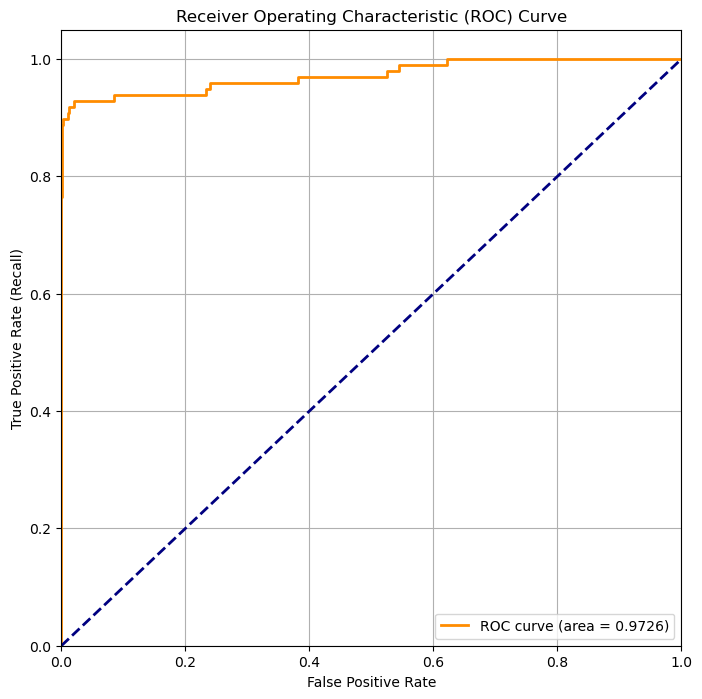

In [19]:
# Implementing and visualizing AUC-ROC
from torchmetrics import AUROC
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
fraud_model.eval()

# Initialize the AUROC class
auroc_metric = AUROC(task='binary').to(device)

all_labels = []
all_probs  = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader_fraud, desc=f"Calculating AUROC"):
        outputs = fraud_model(inputs)
        # For AUROC, we need the probability of the POSITIVE class (class 1)
        probs = F.softmax(outputs, dim=1)[:,1]

        auroc_metric.update(probs, labels)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Compute the final metric
auroc_score = auroc_metric.compute()
print(f"Model AUROC Score {auroc_score*100:.2f}")


# Visualize the ROC Curve using scikit-learn
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



_____________________________________________________

______________________________

____________________________

### Advanced =====> 
> Research the Precision-Recall Curve (PRC) and the AUPRC metric. For severely imbalanced datasets, AUPRC is often considered more informative than AUROC. Implement the AUPRC calculation using torchmetrics.AveragePrecision and plot the curve. Why might focusing on precision and recall be more useful than True/False Positive Rates when the number of true negatives is overwhelmingly large?

Calculating AUPRC:   0%|          | 0/223 [00:00<?, ?it/s]

Calculating AUPRC: 100%|██████████| 223/223 [00:03<00:00, 67.42it/s] 


Model AUPRC Score 85.69


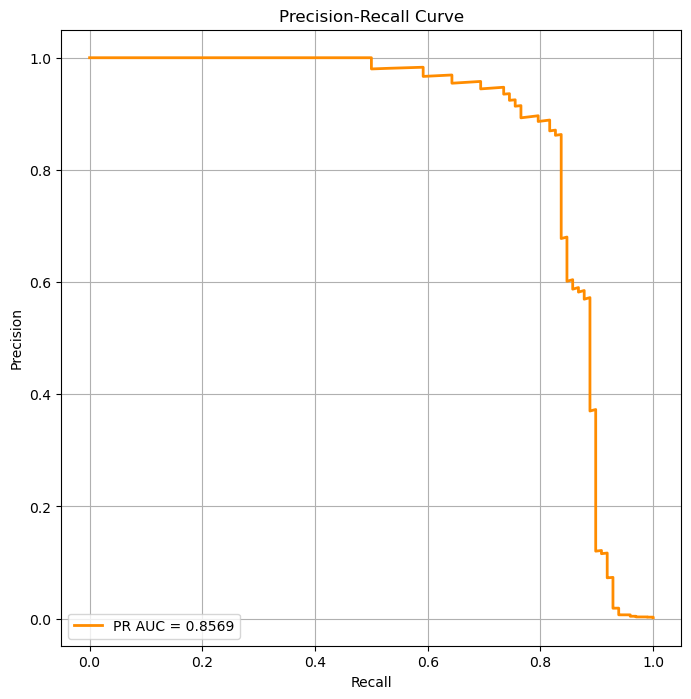

In [30]:
from torchmetrics import AveragePrecision
from sklearn.metrics import precision_recall_curve, auc
import torch.nn.functional as F
fraud_model.eval()

# Initialize the AveragePrecision class
ap_metric = AveragePrecision(task='binary').to(device)

all_labels = []
all_probs  = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader_fraud, desc=f"Calculating AUPRC"):
        outputs = fraud_model(inputs)
        # For AUPRC, we need the probability of the POSITIVE class (class 1)
        probs = F.softmax(outputs, dim=1)[:,1]

        ap_metric.update(probs, labels)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Compute the final metric
ap_score = ap_metric.compute()
print(f"Model AUPRC Score {ap_score*100:.2f}")


from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
pr_auc = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(8, 8))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


_______

______

____
